In [1]:
import torch
print(torch.cuda.get_device_name(0))   # should say Tesla T4

Tesla T4


# Lab | Introduction to LoRA Tuning using PEFT from Hugging Face
<!-- ### Fine-tune a Foundational Model effortlessly -->

**Note:** This is more or less the same notebook you saw in the previous lesson, but that is ok. This is an LLM fine-tuning lab. In class we used a set of datasets and models, and in the labs you are required to change the LLMs models and the datasets including the pre-processing pipelines.


# LoRA Tuning

In this notebook you are being introduced to how to apply LoRA Tuning with the PEFT library to a pre-trained model.

For a complete list of Models compatible with PEFT refer to their [documentation](https://huggingface.co/docs/peft/main/en/index#supported-methods).

A short sample of models families available to be trained with PEFT are: Bloom, Llama, GPT-J, GPT-2, BERT... and more. Hugging Face is working hard to bring more Models to the Library.

## Brief introduction to LoRA Tuning.
LoRA is a re-parameterization technique. Its operation is simple, complex, and brilliant at the same time. It involves reducing the size of the matrices to be trained by dividing them in such a way that when multiplied, they yield the original matrix.

The weights that are modified are those of the reduced matrices, not the original matrix. It's better visualized in an image.

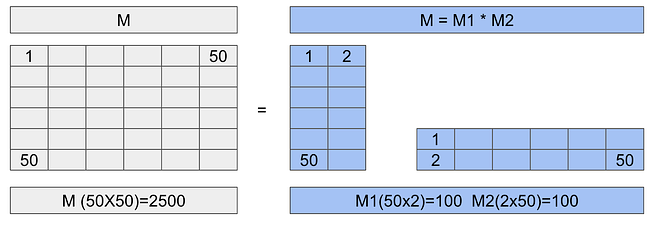

We have an original matrix of 50x50, which means we would have to modify about 2500 parameters. However, as we know, if we multiply two matrices of (2x50) and (50x2), we obtain a 50x50 matrix. Yet, these two matrices are formed by only 100 parameters each. In other words, for the reduced matrices, we need to modify a total of 200 parameters compared to the 2500 of the original matrix. This represents a 92% reduction, and the larger the original matrix, the greater the percentage of savings.

In Language Models like GPT-3 or any of the current ones with LoRA, it's possible that we only need to train about 0.02% of the original parameters. This varies for each model. The best part is that the obtained result is very similar to that of full fine-tuning, in some cases, it can even be better.

# Load the PEFT and Datasets Libraries.

The PEFT library contains the Hugging Face implementation of differente fine-tuning techniques, like LoRA Tuning.

Using the Datasets library we have acces to a huge amount of Datasets.

In [2]:
!pip install -q peft==0.8.2
!pip install -q datasets==2.16.1
!pip install ipywidgets==7.7.5

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.4/183.4 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 507.1/507.1 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.3/115.3 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.4/166.4 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.4/135.4 kB 16.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.12.0 requires fsspec==2025.12.0, but you have fsspec 2023.10.0 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.9/123.9 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 246.9/246.9 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 102.3 MB/s eta 0:00:0000:01
  Attempting uninstall: jupyterlab-widgets
    Found existing installation: jupy

From the transformers library we import the necesary classes to import the model and the tokenizer.

Then we can load the Tokenizer and the model.

Bloom is one of the smallest and smarter model available to be trained with PEFT Library using Prompt Tuning. You can use either of the models in the Bloom Family, I encorage you to use at least two of them and see the differences.

I'm using the smallest one just to spend less time trainig, and avoid memory problems in Colab.

In [3]:
import gc
import os
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

# GPU memory can get split into leftover pieces. This helps PyTorch reuse that space.
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
# Clear GPU memory that is no longer needed before we load the model.
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

model_name = "bigscience/bloom-560m"

tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.padding_side = "right"   # right-padding for TRAINING (we switch to left later, only for generation)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

foundation_model = AutoModelForCausalLM.from_pretrained(
    model_name,
    device_map="auto",
    attn_implementation="eager"   # avoids a known SDPA/padding numerical bug
)
foundation_model.config.pad_token_id = tokenizer.pad_token_id

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


config.json:   0%|          | 0.00/693 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/222 [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 14.5MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.12GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/293 [00:00<?, ?it/s]

## Inference with the pre-trained model.
I'm going to do a test with the pre-trained model without fine-tuning, to see if something changes after the fine-tuning.

In [4]:
def get_outputs(model, inputs, max_new_tokens=100):
    outputs = model.generate(
        input_ids=inputs["input_ids"],
        attention_mask=inputs["attention_mask"],
        max_new_tokens=max_new_tokens,
        repetition_penalty=1.5,
        early_stopping=True,
        eos_token_id=tokenizer.eos_token_id,
        pad_token_id=tokenizer.pad_token_id,
    )
    return outputs

The dataset used for the fine-tuning contains prompts to be used with Large Language Models.

I'm going to request the pre-trained model that acts like a motivational coach.

In [5]:
 #Inference original model
tokenizer.padding_side = "left"   # left-padding for GENERATION
input_sentences = tokenizer("I want you to act as a motivational coach", return_tensors="pt").to(foundation_model.device)
outputs = get_outputs(foundation_model, input_sentences, max_new_tokens=50)
print(tokenizer.batch_decode(outputs, skip_special_tokens=True))

tokenizer.padding_side = "right"  # switch back before we tokenize the training data next

[transformers] The following generation flags are not valid and may be ignored: ['early_stopping']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


["I want you to act as a motivational coach for me.\n- I don't know what you're talking about, but...\nI'm not saying that I'm going out with someone who is just trying and doing it all the time because it's hard work. But if this guy's really good at something he should be"]


Not sure if the answer is correct or not, but for sure is not a prompt. We need to train our model if we want that acts like a motivational coach.

# Preparing the Dataset.
The Dataset used is:

https://huggingface.co/datasets/databricks/databricks-dolly-15k

In [6]:
from datasets import load_dataset

data = load_dataset("fka/awesome-chatgpt-prompts")

def tokenize_function(samples):
    # Long texts use more GPU memory. We cut each prompt to 256 tokens so training can fit on Colab.
    return tokenizer(samples["prompt"], truncation=True, max_length=256)

data = data.map(tokenize_function, batched=True)
train_sample = data["train"].select(range(100))
train_sample = train_sample.remove_columns(["act", "prompt", "for_devs", "type", "contributor"])

print(train_sample)

Generating train split: 0 examples [00:00, ? examples/s]

/usr/local/lib/python3.13/dist-packages/datasets/download/streaming_download_manager.py:778: FutureWarning: The 'verbose' keyword in pd.read_csv is deprecated and will be removed in a future version.
  return pd.read_csv(xopen(filepath_or_buffer, "rb", download_config=download_config), **kwargs)


Map:   0%|          | 0/2169 [00:00<?, ? examples/s]

Dataset({
    features: ['input_ids', 'attention_mask'],
    num_rows: 100
})


# Fine-Tuning.
First is necesary create a LoRA config.


In [7]:
# TARGET_MODULES
# https://github.com/huggingface/peft/blob/39ef2546d5d9b8f5f8a7016ec10657887a867041/src/peft/utils/other.py#L220

from peft import LoraConfig, get_peft_model, PeftModel

lora_config = LoraConfig(
    r=4,
    lora_alpha=1,
    target_modules=["query_key_value"],
    lora_dropout=0.05,
    bias="none",              # fixed — "lora_only" caused exploding gradients → NaN weights
    task_type="CAUSAL_LM"
)

The most important parameter is **r**, it defines how many parameters will be trained. As bigger the valuer more parameters are trained, but it means that the model will be able to learn more complicated relations between input and output.

Yo can find a list of the **target_modules** available on the [Hugging Face Documentation]( https://github.com/huggingface/peft/blob/39ef2546d5d9b8f5f8a7016ec10657887a867041/src/peft/utils/other.py#L220)

**lora_dropout** is like the commom dropout is used to avoid overfitting.

**bias** I was hesitating if use *none* or *lora_only*. For text classification the most common value is none, and for chat or question answering, *all* or *lora_only*.

**task_type**. Indicates the task the model is beign trained for. In this case, text generation.

### Create the PEFT model.



In [8]:
peft_model = get_peft_model(foundation_model, lora_config)
peft_model.print_trainable_parameters()

trainable params: 393,216 || all params: 559,607,808 || trainable%: 0.07026635339584111


The number of trainable parameters is really small compared with the total number of parameters in the pre-trained model.

In [9]:
#Create a directory to contain the Model
import os
working_dir = './'
output_directory = os.path.join(working_dir, "peft_lab_outputs")

In the TrainingArgs we inform the number of epochs we want to train, the output directory and the learning_rate.

GPU memory depends on **how many examples** we process together and **how long those texts** are. Colab GPUs are limited (a T4 has about 15 GB), so we use a batch size of 1.

To still update the weights as if the batch had 8 examples, we use **gradient accumulation**: we run 8 small steps, add up the gradients, then do one weight update. That is the same idea as a larger batch, without keeping 8 full examples in memory at the same time.

If you get `CUDA out of memory`, go to **Runtime → Restart session** and run the notebook from the top. An earlier run can keep using the GPU even after it looks like it stopped.

In [12]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=2,
    per_device_train_batch_size=1,          # one example at a time so we do not run out of GPU memory
    gradient_accumulation_steps=8,          # add gradients over 8 steps, then update (like batch size 8)
    gradient_checkpointing=True,            # save memory: recompute some values during backpropagation instead of storing all of them
    logging_steps=1,
    learning_rate=2e-4,
    report_to="none",
    remove_unused_columns=False,
    max_grad_norm=1.0,        # safety net against gradient explosions
)

Now we can train the model.
To train the model we need:


*   The PEFT Model.
*   The training_args
* The Dataset
* The result of DataCollator, the Dataset ready to be procesed in blocks.





In [11]:

#
# 
# Model training step.
# 
# This cell will take some time to complete (typically ~20 minutes on a T4) ⚠️⚠️
# 
# Training can be time-consuming, even with GPU acceleration. This is one of
# the reasons parameter-efficient fine-tuning methods such as LoRA are used:
# they reduce memory usage and computational requirements by training only a
# small number of additional parameters.
#
#


import transformers
from transformers import Trainer

# LoRA keeps the original model frozen and only trains a few extra weights.
# This line is needed so backpropagation still works when gradient checkpointing is on.
peft_model.enable_input_require_grads()

# Free GPU memory from the generation we ran earlier, before training starts.
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

data_collator = transformers.DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

trainer = Trainer(
    model=peft_model,
    args=training_args,
    train_dataset=train_sample,
    data_collator=data_collator
)

trainer.train()

Step,Training Loss
1,3.600993
2,3.717176
3,3.358431
4,3.285218
5,3.833873
6,3.286347
7,3.499550
8,3.245066
9,3.083062
10,3.106919


TrainOutput(global_step=26, training_loss=3.3282505915715146, metrics={'train_runtime': 27.983, 'train_samples_per_second': 7.147, 'train_steps_per_second': 0.929, 'total_flos': 33524160282624.0, 'train_loss': 3.3282505915715146, 'epoch': 2.0})

In [13]:
#Save the model.
peft_model_path = os.path.join(output_directory, "lora_model")
trainer.model.save_pretrained(peft_model_path)

In [14]:
#Load the Model.
loaded_model = PeftModel.from_pretrained(foundation_model, peft_model_path, is_trainable=False)

## Inference the fine-tuned model.

In [15]:
tokenizer.padding_side = "left"   # left-padding again for generation
input_sentences = tokenizer("I want you to act as a motivational coach", return_tensors="pt").to(loaded_model.device)
outputs = get_outputs(loaded_model, input_sentences, max_new_tokens=100)
print(tokenizer.batch_decode(outputs, skip_special_tokens=True))

["I want you to act as a motivational coach, and provide advice on how the following can be improved:\n1. The first thing I would do is ask your client what they need from me in order for them (or their family) or myself/their friends who are not working hard enough at work but have been given an extra day off because of it - this will help us understand why we feel so frustrated with our job situation.\n2 . If my clients say that there isn't any way around getting more time out during weekdays than"]


# Exercise

- Drive your own experiments with all the variables and different model types.
    - Play with the **lora_config** values, maybe you can achieve a better result in less epochs, saving time and money for your company. :-)


In [16]:
# Testing the model with a different Rank

lora_config_r8 = LoraConfig(
    r=8,                               # ◄ the only thing that changes
    lora_alpha=1,
    target_modules=["query_key_value"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

In [17]:
# free the GPU memory from the first run
del peft_model, loaded_model, trainer
gc.collect(); torch.cuda.empty_cache()

# fresh base model
foundation_model = AutoModelForCausalLM.from_pretrained(model_name, device_map="auto", attn_implementation="eager")
foundation_model.config.pad_token_id = tokenizer.pad_token_id

# wrap it with the r=8 config
peft_model_r8 = get_peft_model(foundation_model, lora_config_r8)
peft_model_r8.print_trainable_parameters()

Loading weights:   0%|          | 0/293 [00:00<?, ?it/s]

trainable params: 786,432 || all params: 560,001,024 || trainable%: 0.14043402892063284


In [18]:
from transformers import Trainer
import transformers

peft_model_r8.enable_input_require_grads()

data_collator = transformers.DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

trainer_r8 = Trainer(
    model=peft_model_r8,
    args=training_args,            # same arguments as the first run
    train_dataset=train_sample,    # already tokenized, still in memory
    data_collator=data_collator
)

trainer_r8.train()                 # note the final training_loss

Step,Training Loss
1,3.600993
2,3.717735
3,3.357006
4,3.281817
5,3.837452
6,3.289602
7,3.503706
8,3.244717
9,3.081349
10,3.107582


TrainOutput(global_step=26, training_loss=3.3237322110396166, metrics={'train_runtime': 27.1073, 'train_samples_per_second': 7.378, 'train_steps_per_second': 0.959, 'total_flos': 33567708168192.0, 'train_loss': 3.3237322110396166, 'epoch': 2.0})

In [19]:
peft_model_r8.eval()               # switch off dropout so the output is repeatable
tokenizer.padding_side = "left"    # left padding for generation
input_sentences = tokenizer("I want you to act as a motivational coach", return_tensors="pt").to(peft_model_r8.device)
outputs = get_outputs(peft_model_r8, input_sentences, max_new_tokens=100)
print(tokenizer.batch_decode(outputs, skip_special_tokens=True))

tokenizer.padding_side = "right"   # back to right before the next training

['I want you to act as a motivational coach. You will be able to:\n• Provide advice and support on how best we can achieve our goals, in order for us not only get the results that are desired but also make it easier than ever.\nThe first step is identifying what your clients need from me; I am an experienced professional who has been working with people since 2000 (mostly young adults). My experience includes coaching individuals through their personal journey of success or failure - whether they have struggled financial hardships such as: divorce/separ']


In [22]:
eval_sample = data["train"].select(range(100, 153)).remove_columns(["act", "prompt", "for_devs", "type", "contributor"])

In [23]:
import pandas as pd
results = []   # run this once, at the start

def log_run(name, peft_model, trainer, eval_sample):
    trainable = sum(p.numel() for p in peft_model.parameters() if p.requires_grad)
    losses = [h["loss"] for h in trainer.state.log_history if "loss" in h]
    results.append({
        "run": name,
        "trainable": trainable,
        "train_loss": round(sum(losses) / len(losses), 3),
        "eval_loss": round(trainer.evaluate(eval_dataset=eval_sample)["eval_loss"], 3),
    })
    return pd.DataFrame(results)

log_run("r=8", peft_model_r8, trainer_r8, eval_sample)   # call it after each training

Training Loss,Validation Loss,Step
2.956768,3.198189,26


,run,trainable,train_loss,eval_loss
0,r=8,786432,3.324,3.198


In [24]:
# Testing the model with a different Rank

lora_config_r16 = LoraConfig(
    r=16,                              # ◄ the only thing that changes
    lora_alpha=1,
    target_modules=["query_key_value"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

In [26]:
# free the r=8 run
del peft_model_r8, trainer_r8
gc.collect(); torch.cuda.empty_cache()

# fresh base model
foundation_model = AutoModelForCausalLM.from_pretrained(model_name, device_map="auto", attn_implementation="eager")
foundation_model.config.pad_token_id = tokenizer.pad_token_id

# wrap it with the r=16 config
peft_model_r16 = get_peft_model(foundation_model, lora_config_r16)
peft_model_r16.print_trainable_parameters()

Loading weights:   0%|          | 0/293 [00:00<?, ?it/s]

trainable params: 1,572,864 || all params: 560,787,456 || trainable%: 0.2804741766549072


In [27]:
peft_model_r16.enable_input_require_grads()

trainer_r16 = Trainer(
    model=peft_model_r16,
    args=training_args,
    train_dataset=train_sample,
    data_collator=data_collator
)

trainer_r16.train()                # note the final training loss

Step,Training Loss
1,3.600993
2,3.714667
3,3.357347
4,3.280913
5,3.840920
6,3.288142
7,3.507295
8,3.249285
9,3.087577
10,3.123166


TrainOutput(global_step=26, training_loss=3.3383691769379835, metrics={'train_runtime': 27.0089, 'train_samples_per_second': 7.405, 'train_steps_per_second': 0.963, 'total_flos': 33654803939328.0, 'train_loss': 3.3383691769379835, 'epoch': 2.0})

In [28]:
log_run("r=16", peft_model_r16, trainer_r16, eval_sample)

Training Loss,Validation Loss,Step
2.996379,3.222731,26


,run,trainable,train_loss,eval_loss
0,r=8,786432,3.324,3.198
1,r=16,1572864,3.338,3.223


In [29]:
peft_model_r16.eval()              # switch off dropout so the output is repeatable
tokenizer.padding_side = "left"    # left padding for generation
input_sentences = tokenizer("I want you to act as a motivational coach", return_tensors="pt").to(peft_model_r16.device)
outputs = get_outputs(peft_model_r16, input_sentences, max_new_tokens=100)
print(tokenizer.batch_decode(outputs, skip_special_tokens=True))

tokenizer.padding_side = "right"   # back to right before the next training

['I want you to act as a motivational coach and help your clients achieve their goals. I am looking for someone who is able to: 1) provide an engaging, stimulating presentation of the topic; 2). Provide advice on how best approach this subject in order that it can be used by others (evaluator or peer reviewer), 3).\nThe following are examples from my book: "When You Want To Be A Motivating Coach" - The author describes his experience with people seeking motivation through coaching services.\nA person has been asked']


In [30]:
# free the r=16 run
del peft_model_r16, trainer_r16
gc.collect(); torch.cuda.empty_cache()

# fresh base model + the r=4 adapter the lab saved
foundation_model = AutoModelForCausalLM.from_pretrained(model_name, device_map="auto", attn_implementation="eager")
foundation_model.config.pad_token_id = tokenizer.pad_token_id
model_r4 = PeftModel.from_pretrained(foundation_model, peft_model_path, is_trainable=False)

# evaluate it on the same held-out rows
eval_trainer = Trainer(model=model_r4, args=training_args, data_collator=data_collator)
eval_loss_r4 = eval_trainer.evaluate(eval_dataset=eval_sample)["eval_loss"]

# add the row by hand
results.append({"run": "r=4", "trainable": 393216, "train_loss": None, "eval_loss": round(eval_loss_r4, 3)})
pd.DataFrame(results)

Loading weights:   0%|          | 0/293 [00:00<?, ?it/s]

Training Loss,Validation Loss,Step
No log,3.195715,0


,run,trainable,train_loss,eval_loss
0,r=8,786432,3.324,3.198
1,r=16,1572864,3.338,3.223
2,r=4,393216,NaN,3.196


In [31]:
# free the r=4 evaluation objects
del model_r4, eval_trainer
gc.collect(); torch.cuda.empty_cache()

# fresh base model
foundation_model = AutoModelForCausalLM.from_pretrained(model_name, device_map="auto", attn_implementation="eager")
foundation_model.config.pad_token_id = tokenizer.pad_token_id

# config + wrap (r=2)
lora_config_r2 = LoraConfig(r=2, lora_alpha=1, target_modules=["query_key_value"],
                            lora_dropout=0.05, bias="none", task_type="CAUSAL_LM")
peft_model_r2 = get_peft_model(foundation_model, lora_config_r2)
peft_model_r2.print_trainable_parameters()      # should show 196,608

# train
peft_model_r2.enable_input_require_grads()
trainer_r2 = Trainer(model=peft_model_r2, args=training_args,
                     train_dataset=train_sample, data_collator=data_collator)
trainer_r2.train()

# add the row to the table
log_run("r=2", peft_model_r2, trainer_r2, eval_sample)

# generate
peft_model_r2.eval()
tokenizer.padding_side = "left"
input_sentences = tokenizer("I want you to act as a motivational coach", return_tensors="pt").to(peft_model_r2.device)
outputs = get_outputs(peft_model_r2, input_sentences, max_new_tokens=100)
print(tokenizer.batch_decode(outputs, skip_special_tokens=True))
tokenizer.padding_side = "right"

Loading weights:   0%|          | 0/293 [00:00<?, ?it/s]

trainable params: 196,608 || all params: 559,411,200 || trainable%: 0.03514552443712246


Step,Training Loss
1,3.600993
2,3.716946
3,3.353795
4,3.280353
5,3.837538
6,3.287652
7,3.500988
8,3.231809
9,3.074138
10,3.107851


Training Loss,Validation Loss,Step
3.053649,3.391572,26


['I want you to act as a motivational coach. I would like the client (a person who is currently working on an idea for which there are no specific recommendations, but rather suggestions of what it might be possible that they can provide in their own words) and me "ask" about how much time should take them "to develop my ideas into something meaningful enough so people will find useful information relevant from other sources such as:\n1 -How do we get more work done? 2 – How does this help us achieve our goals 3 • What type(']


In [32]:
# free the r=2 run
del peft_model_r2, trainer_r2
gc.collect(); torch.cuda.empty_cache()

# fresh base model
foundation_model = AutoModelForCausalLM.from_pretrained(model_name, device_map="auto", attn_implementation="eager")
foundation_model.config.pad_token_id = tokenizer.pad_token_id

# config + wrap (r=1)
lora_config_r1 = LoraConfig(r=1, lora_alpha=1, target_modules=["query_key_value"],
                            lora_dropout=0.05, bias="none", task_type="CAUSAL_LM")
peft_model_r1 = get_peft_model(foundation_model, lora_config_r1)
peft_model_r1.print_trainable_parameters()      # should show 98,304

# train
peft_model_r1.enable_input_require_grads()
trainer_r1 = Trainer(model=peft_model_r1, args=training_args,
                     train_dataset=train_sample, data_collator=data_collator)
trainer_r1.train()

# add the row and show all runs
table = log_run("r=1", peft_model_r1, trainer_r1, eval_sample)
display(table.sort_values("trainable").reset_index(drop=True))

# generate
peft_model_r1.eval()
tokenizer.padding_side = "left"
input_sentences = tokenizer("I want you to act as a motivational coach", return_tensors="pt").to(peft_model_r1.device)
outputs = get_outputs(peft_model_r1, input_sentences, max_new_tokens=100)
print(tokenizer.batch_decode(outputs, skip_special_tokens=True))
tokenizer.padding_side = "right"

Loading weights:   0%|          | 0/293 [00:00<?, ?it/s]

trainable params: 98,304 || all params: 559,312,896 || trainable%: 0.01757585078102687


Step,Training Loss
1,3.600993
2,3.716983
3,3.380789
4,3.291546
5,3.870913
6,3.325822
7,3.510979
8,3.226498
9,3.094720
10,3.106027


Training Loss,Validation Loss,Step
3.468295,3.709778,26


,run,trainable,train_loss,eval_loss
0,r=1,98304,3.567,3.710
1,r=2,196608,3.406,3.392
2,r=4,393216,NaN,3.196
3,r=8,786432,3.324,3.198
4,r=16,1572864,3.338,3.223


['I want you to act as a motivational coach. I will be working with your clients\' needs and goals in the first place, but also provide suggestions for how they can achieve their personal or professional objectives.\nThe following are some examples of what is called "other" requirements:\nIf you\'re looking at an individual\'s needs: 1) being able to: (1). understand why this person should not do something about other things 2.) have access only from within that area 3) . require information on specific topics 4 . ask questions 5 ) request help 6']


In [33]:
alphas = [1, 2, 4, 8, 16]

# free the r=1 run
del peft_model_r1, trainer_r1
gc.collect(); torch.cuda.empty_cache()

for alpha in alphas:
    # fresh base model every time
    foundation_model = AutoModelForCausalLM.from_pretrained(model_name, device_map="auto", attn_implementation="eager")
    foundation_model.config.pad_token_id = tokenizer.pad_token_id

    # r stays at 4, only alpha changes
    cfg = LoraConfig(r=4, lora_alpha=alpha, target_modules=["query_key_value"],
                     lora_dropout=0.05, bias="none", task_type="CAUSAL_LM")
    peft_model_a = get_peft_model(foundation_model, cfg)

    # train
    peft_model_a.enable_input_require_grads()
    trainer_a = Trainer(model=peft_model_a, args=training_args,
                        train_dataset=train_sample, data_collator=data_collator)
    trainer_a.train()

    # add the row and show the table with all runs so far
    table = log_run(f"r=4, alpha={alpha}", peft_model_a, trainer_a, eval_sample)
    display(table.reset_index(drop=True))
    print("best so far:", table.loc[table["eval_loss"].idxmin(), "run"])

    # generate
    peft_model_a.eval()
    tokenizer.padding_side = "left"
    input_sentences = tokenizer("I want you to act as a motivational coach", return_tensors="pt").to(peft_model_a.device)
    outputs = get_outputs(peft_model_a, input_sentences, max_new_tokens=100)
    print(f"--- text for alpha={alpha} ---")
    print(tokenizer.batch_decode(outputs, skip_special_tokens=True))
    tokenizer.padding_side = "right"

    # free memory before the next alpha
    del peft_model_a, trainer_a, foundation_model
    gc.collect(); torch.cuda.empty_cache()

Loading weights:   0%|          | 0/293 [00:00<?, ?it/s]

Step,Training Loss
1,3.600993
2,3.719333
3,3.352382
4,3.281759
5,3.833835
6,3.285369
7,3.501203
8,3.242393
9,3.079333
10,3.106377


Training Loss,Validation Loss,Step
2.964893,3.225759,26


,run,trainable,train_loss,eval_loss
0,r=8,786432,3.324,3.198
1,r=16,1572864,3.338,3.223
2,r=4,393216,NaN,3.196
3,r=2,196608,3.406,3.392
4,r=1,98304,3.567,3.710
5,"r=4, alpha=1",393216,3.335,3.226


best so far: r=4
--- text for alpha=1 ---
["I want you to act as a motivational coach, and help your clients achieve their goals. I am looking for someone who is passionate about helping people reach the best possible results in life by using positive strategies that are easy-to-implement.\nThe goal of this post will be an introduction on how we can use our own personal experience with success stories from successful individuals (and not just those published online) so they could share it here at my website or blog site! The first part would describe what makes me different:\nMy name's John Burr"]


...

Loading weights:   0%|          | 0/293 [00:00<?, ?it/s]

Step,Training Loss
1,3.600993
2,3.704149
3,3.375865
4,11.086111
5,15.525229
6,15.831829
7,15.072356
8,15.724150
9,18.387394
10,22.278294


Training Loss,Validation Loss,Step
0.000000,nan,26


,run,trainable,train_loss,eval_loss
0,r=8,786432,3.324,3.198
1,r=16,1572864,3.338,3.223
2,r=4,393216,NaN,3.196
3,r=2,196608,3.406,3.392
4,r=1,98304,3.567,3.710
5,"r=4, alpha=1",393216,3.335,3.226
6,"r=4, alpha=2",393216,3.614,3.575
7,"r=4, alpha=4",393216,10.742,13.606
8,"r=4, alpha=8",393216,8.580,NaN
9,"r=4, alpha=16",393216,8.697,NaN


best so far: r=4
--- text for alpha=16 ---
['I want you to act as a motivational coach']


In [34]:
import copy

epochs_list = [1, 2, 3, 4]

for ep in epochs_list:
    foundation_model = AutoModelForCausalLM.from_pretrained(model_name, device_map="auto", attn_implementation="eager")
    foundation_model.config.pad_token_id = tokenizer.pad_token_id

    cfg = LoraConfig(r=4, lora_alpha=1, target_modules=["query_key_value"],
                     lora_dropout=0.05, bias="none", task_type="CAUSAL_LM")
    peft_model_e = get_peft_model(foundation_model, cfg)
    peft_model_e.enable_input_require_grads()

    args_e = copy.deepcopy(training_args)   # same settings as before...
    args_e.num_train_epochs = ep            # ...except the epochs

    trainer_e = Trainer(model=peft_model_e, args=args_e,
                        train_dataset=train_sample, data_collator=data_collator)
    trainer_e.train()

    table = log_run(f"r=4, alpha=1, epochs={ep}", peft_model_e, trainer_e, eval_sample)
    display(table.reset_index(drop=True))
    print("best so far:", table.loc[table["eval_loss"].idxmin(), "run"])

    del peft_model_e, trainer_e, foundation_model
    gc.collect(); torch.cuda.empty_cache()
    

Loading weights:   0%|          | 0/293 [00:00<?, ?it/s]

Step,Training Loss
1,3.600993
2,3.719333
3,3.356439
4,3.281268
5,3.835007
6,3.288182
7,3.516031
8,3.257611
9,3.092885
10,3.133706


Training Loss,Validation Loss,Step
3.770271,3.326330,13


,run,trainable,train_loss,eval_loss
0,r=8,786432,3.324,3.198
1,r=16,1572864,3.338,3.223
2,r=4,393216,NaN,3.196
3,r=2,196608,3.406,3.392
4,r=1,98304,3.567,3.710
5,"r=4, alpha=1",393216,3.335,3.226
6,"r=4, alpha=2",393216,3.614,3.575
7,"r=4, alpha=4",393216,10.742,13.606
8,"r=4, alpha=8",393216,8.580,NaN
9,"r=4, alpha=16",393216,8.697,NaN


best so far: r=4


...

Loading weights:   0%|          | 0/293 [00:00<?, ?it/s]

Step,Training Loss
1,3.600993
2,3.721875
3,3.357720
4,3.283840
5,3.825659
6,3.281563
7,3.497580
8,3.229707
9,3.058920
10,3.082188


Training Loss,Validation Loss,Step
2.826553,3.219435,52


,run,trainable,train_loss,eval_loss
0,r=8,786432,3.324,3.198
1,r=16,1572864,3.338,3.223
2,r=4,393216,NaN,3.196
3,r=2,196608,3.406,3.392
4,r=1,98304,3.567,3.710
5,"r=4, alpha=1",393216,3.335,3.226
6,"r=4, alpha=2",393216,3.614,3.575
7,"r=4, alpha=4",393216,10.742,13.606
8,"r=4, alpha=8",393216,8.580,NaN
9,"r=4, alpha=16",393216,8.697,NaN


best so far: r=4


In [35]:
model_name_1b = "bigscience/bloom-1b1"
tokenizer_1b = AutoTokenizer.from_pretrained(model_name_1b)   # same vocabulary as 560m, so train_sample still fits
print(tokenizer_1b.pad_token_id, tokenizer.pad_token_id)      # should match

gc.collect(); torch.cuda.empty_cache()

foundation_model = AutoModelForCausalLM.from_pretrained(model_name_1b, device_map="auto", attn_implementation="eager")
foundation_model.config.pad_token_id = tokenizer.pad_token_id

cfg = LoraConfig(r=4, lora_alpha=1, target_modules=["query_key_value"],
                 lora_dropout=0.05, bias="none", task_type="CAUSAL_LM")
peft_model_1b = get_peft_model(foundation_model, cfg)
peft_model_1b.enable_input_require_grads()

args_1b = copy.deepcopy(training_args)
args_1b.num_train_epochs = 2

trainer_1b = Trainer(model=peft_model_1b, args=args_1b,
                     train_dataset=train_sample, data_collator=data_collator)
trainer_1b.train()

table = log_run("bloom-1b1, r=4, alpha=1, epochs=2", peft_model_1b, trainer_1b, eval_sample)
display(table.reset_index(drop=True))
print("best so far:", table.loc[table["eval_loss"].idxmin(), "run"])

del peft_model_1b, trainer_1b, foundation_model
gc.collect(); torch.cuda.empty_cache()

config.json:   0%|          | 0.00/693 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/222 [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 14.5MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/293 [00:00<?, ?it/s]

Step,Training Loss
1,3.425330
2,3.581714
3,3.222632
4,3.165677
5,3.723463
6,3.156851
7,3.418085
8,3.053125
9,2.931986
10,2.976918


Training Loss,Validation Loss,Step
2.742769,3.003120,26


,run,trainable,train_loss,eval_loss
0,r=8,786432,3.324,3.198
1,r=16,1572864,3.338,3.223
2,r=4,393216,NaN,3.196
3,r=2,196608,3.406,3.392
4,r=1,98304,3.567,3.710
5,"r=4, alpha=1",393216,3.335,3.226
6,"r=4, alpha=2",393216,3.614,3.575
7,"r=4, alpha=4",393216,10.742,13.606
8,"r=4, alpha=8",393216,8.580,NaN
9,"r=4, alpha=16",393216,8.697,NaN


best so far: bloom-1b1, r=4, alpha=1, epochs=2


In [36]:
import copy

# (name, r, alpha, epochs)
runs_1b = [
    ("bloom-1b1, r=2, alpha=1, epochs=2", 2, 1, 2),
    ("bloom-1b1, r=8, alpha=1, epochs=2", 8, 1, 2),
    ("bloom-1b1, r=4, alpha=2, epochs=2", 4, 2, 2),
    ("bloom-1b1, r=4, alpha=1, epochs=1", 4, 1, 1),
    ("bloom-1b1, r=4, alpha=1, epochs=3", 4, 1, 3),
    ("bloom-1b1, r=4, alpha=1, epochs=4", 4, 1, 4),
]

for name, r, alpha, ep in runs_1b:
    foundation_model = AutoModelForCausalLM.from_pretrained(model_name_1b, device_map="auto", attn_implementation="eager")
    foundation_model.config.pad_token_id = tokenizer.pad_token_id

    cfg = LoraConfig(r=r, lora_alpha=alpha, target_modules=["query_key_value"],
                     lora_dropout=0.05, bias="none", task_type="CAUSAL_LM")
    peft_model_x = get_peft_model(foundation_model, cfg)
    peft_model_x.enable_input_require_grads()

    args_x = copy.deepcopy(training_args)
    args_x.num_train_epochs = ep

    trainer_x = Trainer(model=peft_model_x, args=args_x,
                        train_dataset=train_sample, data_collator=data_collator)
    trainer_x.train()

    table = log_run(name, peft_model_x, trainer_x, eval_sample)
    table.to_csv("results.csv", index=False)          # backup after every run
    display(table.reset_index(drop=True))
    print("best so far:", table.loc[table["eval_loss"].idxmin(), "run"])

    del peft_model_x, trainer_x, foundation_model
    gc.collect(); torch.cuda.empty_cache()

Loading weights:   0%|          | 0/293 [00:00<?, ?it/s]

Step,Training Loss
1,3.425330
2,3.581884
3,3.223381
4,3.166894
5,3.725209
6,3.155675
7,3.422812
8,3.054867
9,2.936868
10,2.986242


Training Loss,Validation Loss,Step
2.743869,3.015664,26


,run,trainable,train_loss,eval_loss
0,r=8,786432,3.324,3.198
1,r=16,1572864,3.338,3.223
2,r=4,393216,NaN,3.196
3,r=2,196608,3.406,3.392
4,r=1,98304,3.567,3.710
5,"r=4, alpha=1",393216,3.335,3.226
6,"r=4, alpha=2",393216,3.614,3.575
7,"r=4, alpha=4",393216,10.742,13.606
8,"r=4, alpha=8",393216,8.580,NaN
9,"r=4, alpha=16",393216,8.697,NaN


best so far: bloom-1b1, r=4, alpha=1, epochs=2


...

Loading weights:   0%|          | 0/293 [00:00<?, ?it/s]

Step,Training Loss
1,3.425330
2,3.581960
3,3.223499
4,3.167809
5,3.726747
6,3.159018
7,3.423021
8,3.051033
9,2.928816
10,3.010080


Training Loss,Validation Loss,Step
2.424017,2.840296,52


,run,trainable,train_loss,eval_loss
0,r=8,786432,3.324,3.198
1,r=16,1572864,3.338,3.223
2,r=4,393216,NaN,3.196
3,r=2,196608,3.406,3.392
4,r=1,98304,3.567,3.710
5,"r=4, alpha=1",393216,3.335,3.226
6,"r=4, alpha=2",393216,3.614,3.575
7,"r=4, alpha=4",393216,10.742,13.606
8,"r=4, alpha=8",393216,8.580,NaN
9,"r=4, alpha=16",393216,8.697,NaN


best so far: bloom-1b1, r=4, alpha=1, epochs=4


In [37]:
from datasets import load_dataset
import pandas as pd

def run_dataset(ds_name, text_col, label, r=4, alpha=1, epochs=2):
    ds = load_dataset(ds_name)["train"].shuffle(seed=42)   # shuffle: some datasets (imdb) are sorted by label
    print(label, "columns:", ds.column_names)

    def tok(samples):
        return tokenizer(samples[text_col], truncation=True, max_length=256)

    ds = ds.map(tok, batched=True, remove_columns=ds.column_names)
    train_new = ds.select(range(100))
    eval_new = ds.select(range(100, 153))

    model = AutoModelForCausalLM.from_pretrained(model_name, device_map="auto", attn_implementation="eager")
    model.config.pad_token_id = tokenizer.pad_token_id

    # 1) baseline: the untuned model on the held-out rows
    base_eval = Trainer(model=model, args=training_args, data_collator=data_collator).evaluate(eval_dataset=eval_new)
    results.append({"run": f"{label} BASE (no tuning)", "trainable": 0,
                    "train_loss": float("nan"), "eval_loss": round(base_eval["eval_loss"], 3)})

    # 2) LoRA with our best 560m setup
    cfg = LoraConfig(r=r, lora_alpha=alpha, target_modules=["query_key_value"],
                     lora_dropout=0.05, bias="none", task_type="CAUSAL_LM")
    peft_m = get_peft_model(model, cfg)
    peft_m.enable_input_require_grads()
    args_d = copy.deepcopy(training_args)
    args_d.num_train_epochs = epochs
    trainer_d = Trainer(model=peft_m, args=args_d, train_dataset=train_new, data_collator=data_collator)
    trainer_d.train()

    table = log_run(f"{label} r={r}, alpha={alpha}, epochs={epochs}", peft_m, trainer_d, eval_new)
    table.to_csv("results.csv", index=False)
    display(table.reset_index(drop=True))

    del peft_m, trainer_d, model
    gc.collect(); torch.cuda.empty_cache()

run_dataset("Abirate/english_quotes", "quote", "quotes")
run_dataset("imdb", "text", "imdb")

Generating train split: 0 examples [00:00, ? examples/s]

quotes columns: ['quote', 'author', 'tags']


Map:   0%|          | 0/2508 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/293 [00:00<?, ?it/s]

Training Loss,Validation Loss,Step
No log,3.339095,0


Step,Training Loss
1,3.153454
2,3.124943
3,3.712421
4,3.569737
5,3.958025
6,3.828100
7,3.403602
8,2.977488
9,3.649862
10,3.337483


Training Loss,Validation Loss,Step
2.881970,3.209498,26


,run,trainable,train_loss,eval_loss
0,r=8,786432,3.324,3.198
1,r=16,1572864,3.338,3.223
2,r=4,393216,NaN,3.196
3,r=2,196608,3.406,3.392
4,r=1,98304,3.567,3.710
5,"r=4, alpha=1",393216,3.335,3.226
6,"r=4, alpha=2",393216,3.614,3.575
7,"r=4, alpha=4",393216,10.742,13.606
8,"r=4, alpha=8",393216,8.580,NaN
9,"r=4, alpha=16",393216,8.697,NaN


HfUriError: Invalid HF URI 'hf://datasets/imdb@e6281661ce1c48d982bc483cf8a173c1bbeb5d31/plain_text/train-*'. Repository id must be 'namespace/name', got 'imdb'.

In [38]:
run_dataset("stanfordnlp/imdb", "text", "imdb")

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

imdb columns: ['text', 'label']


Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/293 [00:00<?, ?it/s]

Training Loss,Validation Loss,Step
No log,3.817486,0


Step,Training Loss
1,3.832599
2,3.591962
3,3.736769
4,3.719310
5,3.746179
6,3.953322
7,3.301563
8,3.621589
9,3.707402
10,3.585310


Training Loss,Validation Loss,Step
4.031582,3.909617,26


,run,trainable,train_loss,eval_loss
0,r=8,786432,3.324,3.198
1,r=16,1572864,3.338,3.223
2,r=4,393216,NaN,3.196
3,r=2,196608,3.406,3.392
4,r=1,98304,3.567,3.710
5,"r=4, alpha=1",393216,3.335,3.226
6,"r=4, alpha=2",393216,3.614,3.575
7,"r=4, alpha=4",393216,10.742,13.606
8,"r=4, alpha=8",393216,8.580,NaN
9,"r=4, alpha=16",393216,8.697,NaN


In [39]:
## Best setup for the 560m model: bloom-1b1, r=4, alpha=1, epochs=4	589824	2.818	2.840